In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# here we are loading train data 
df_train = pd.read_csv("/kaggle/input/titanic/train.csv")

In [4]:
df=df_train.copy()

In [5]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Görselleştirme

# VERİ öN işLEME

Model öncesi; eksik veri doldurma

anlamsız değişkenlerin çıkarılması

varsa aykırı değer analizi

korelasyon

Modele konulacak değişkenlerin belirlenmesi

Kategorik değişkenlerin dönüşümü

# Eksik veri doldurma

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

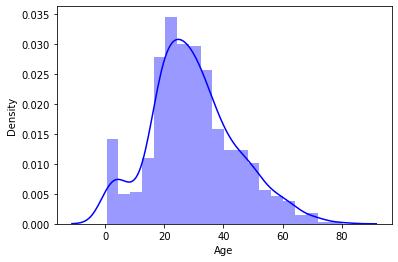

In [8]:
#plt.figure(figsize=(10,8))
sns.distplot(df.Age, color="blue")

In [9]:
# Age değişkeni normale yakın dağılım gösterdiği için eksik verileri mean ile dolduracağız.
df["Age"].fillna(df["Age"].mean(),inplace=True)

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
#Cabin'in doldurulmasına gerek yoktur. Çünkü anlamlı bir değişken değildir.
df.Cabin.value_counts()

B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: Cabin, Length: 147, dtype: int64

In [12]:
df["Embarked"].mode()

0    S
dtype: object

In [13]:
df["Embarked"].mode()[0]

'S'

In [14]:
#embarked değişkeni kategorik olduğu için mode ile dolduruldu. mode()[0] = "S"
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

In [15]:
num_cols=df[["Age","SibSp","Fare","Parch"]]

<AxesSubplot:>

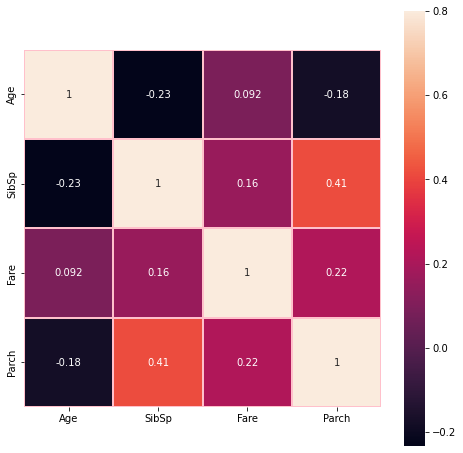

In [16]:
import matplotlib.pyplot as plt
corr=num_cols.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr, vmax=.8, linewidths=0.05,square=True,annot=True,linecolor="pink")

In [17]:
korelasyon=df[["Age","SibSp","Fare","Parch","Survived"]]

<AxesSubplot:>

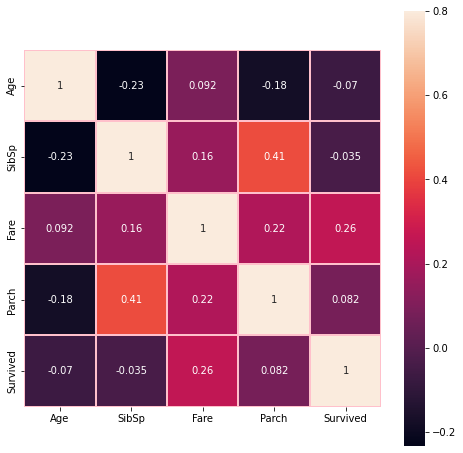

In [18]:
import matplotlib.pyplot as plt
corr=korelasyon.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr, vmax=.8, linewidths=0.05,square=True,annot=True,linecolor="pink")

In [19]:
cat_cols=df[["Survived","Pclass","Sex","Embarked"]]

In [20]:
cat_cols.head(5)

,Survived,Pclass,Sex,Embarked
0,0,3,male,S
1,1,1,female,C
2,1,3,female,S
3,1,1,female,S
4,0,3,male,S


In [21]:
map_new = {"male":0, "female":1}
cat_cols["Sex"]= cat_cols["Sex"].map(map_new)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [22]:
cat_cols.head(5)

,Survived,Pclass,Sex,Embarked
0,0,3,0,S
1,1,1,1,C
2,1,3,1,S
3,1,1,1,S
4,0,3,0,S


In [23]:
# pclass değişimi model sonrası yap (sonuçları kontrol et)